***Enunciado***

Muchos objetos astrofísicos fascinantes (núcleos galácticos activos, hipernovas, binarias de rayos X) pueden explicarse con los fenómenos que ocurren en los denominados discos de acreción alrededor de agujeros negros. En este proyecto se usa lo visto en el curso de Relatividad y Gravitación para estudiar ese problema.


El objetivo de este trabajo es desarrollar simulaciones y cálculos útiles que permitan comparar la emisión local del disco con la observada desde distintos ángulos, usando los efectos relativistas de: 

- factor de Lorentz y velocidad relativista,
- beaming relativista y aberración de la luz,
- desplazamiento Doppler,
- corrimiento al rojo gravitacional en el potencial de Schwarzschild.

En el notebook se modela un disco de acreción con dinámica newtoniana para las partículas del gas, y se incorporan correcciones relativistas para el flujo observado y la longitud de onda observada. Las ideas fundamentales se toman de los notebooks de clase.

***Criterios usados en este notebook***

- Simulación de la dinámica orbital de partículas en un disco kepleriano.
- Cálculo de la emisión térmica del disco con perfil de temperatura tipo Shakura-Sunyaev.
- Correcciones relativistas de beaming y desplazamiento espectral.
- Visualización de mapas de flujo y perfiles radiales para diferentes inclinaciones.


   DISCO DE ACRECIÓN — Simulación Relativista
   M_BH = 10 M☉  |  Rs = 3.12e-12 años-luz = 29.54 km
   ISCO = 9.37e-12 años-luz = 88.62 km
   Unidades: L = año-luz, T = año, G = 1.561e-13 (años-luz)³/(M_sun·año²)

 Simulando partículas (dinámica newtoniana)…
       10000 partículas simuladas.

 Calculando mapas de emisión (beaming + redshift) — Ángulos positivos…


/var/folders/lq/q6gckjc95cs95tcthk478wf80000gn/T/ipykernel_1203/316311181.py:319: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(X, Y, F_log, cmap=cmap_flux, shading='auto')


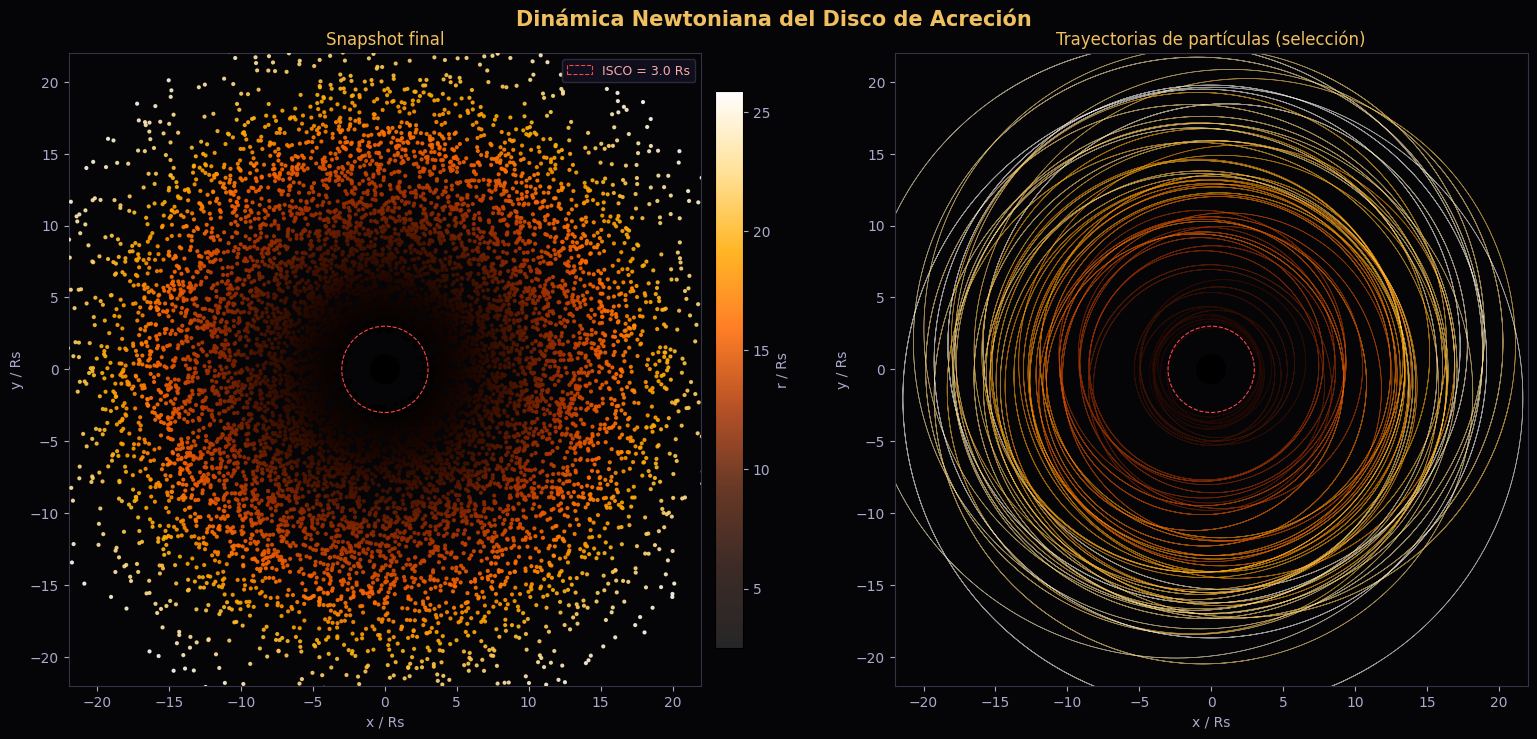

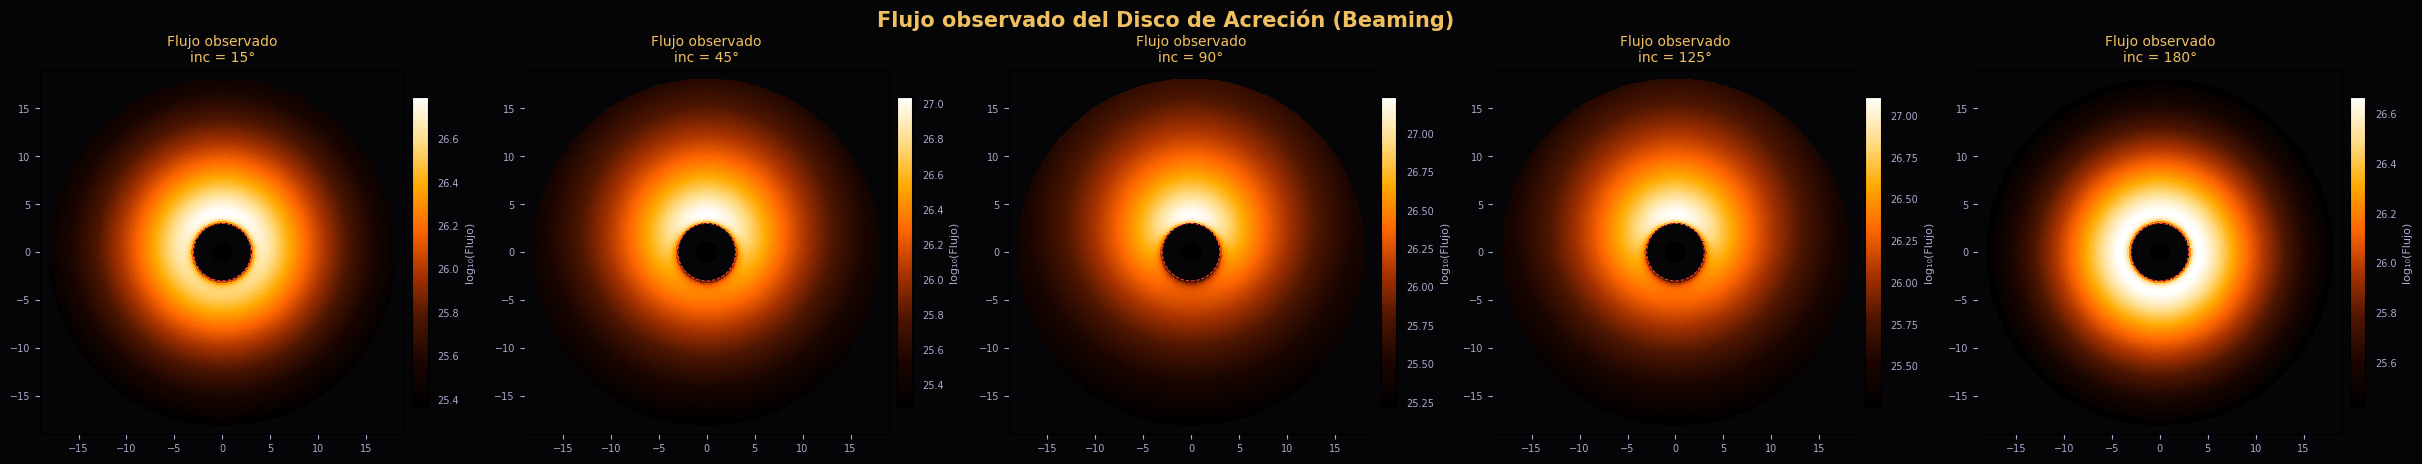

/var/folders/lq/q6gckjc95cs95tcthk478wf80000gn/T/ipykernel_1203/316311181.py:362: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(X, Y, ratio, cmap=cmap_shift, shading='auto', vmin=0.6, vmax=1.4)


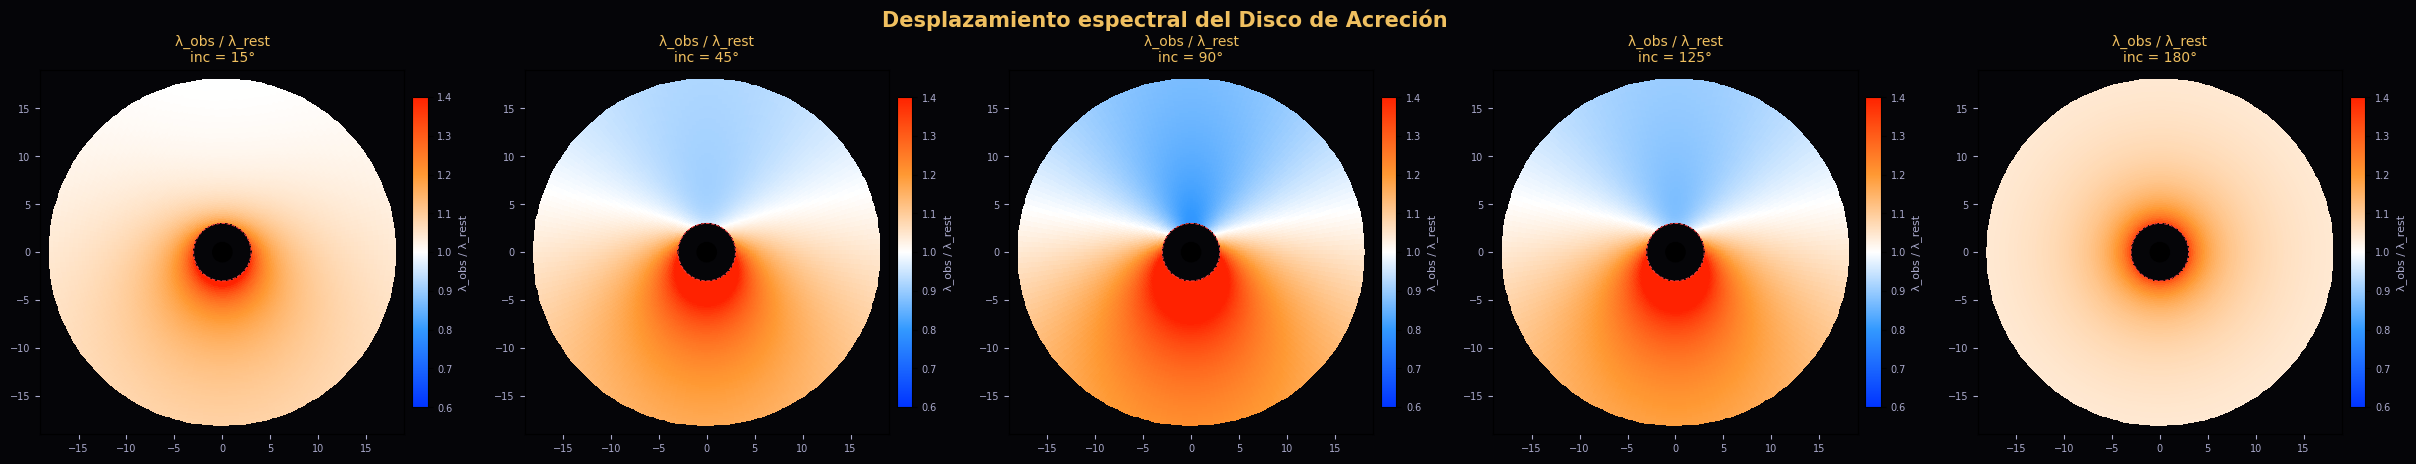

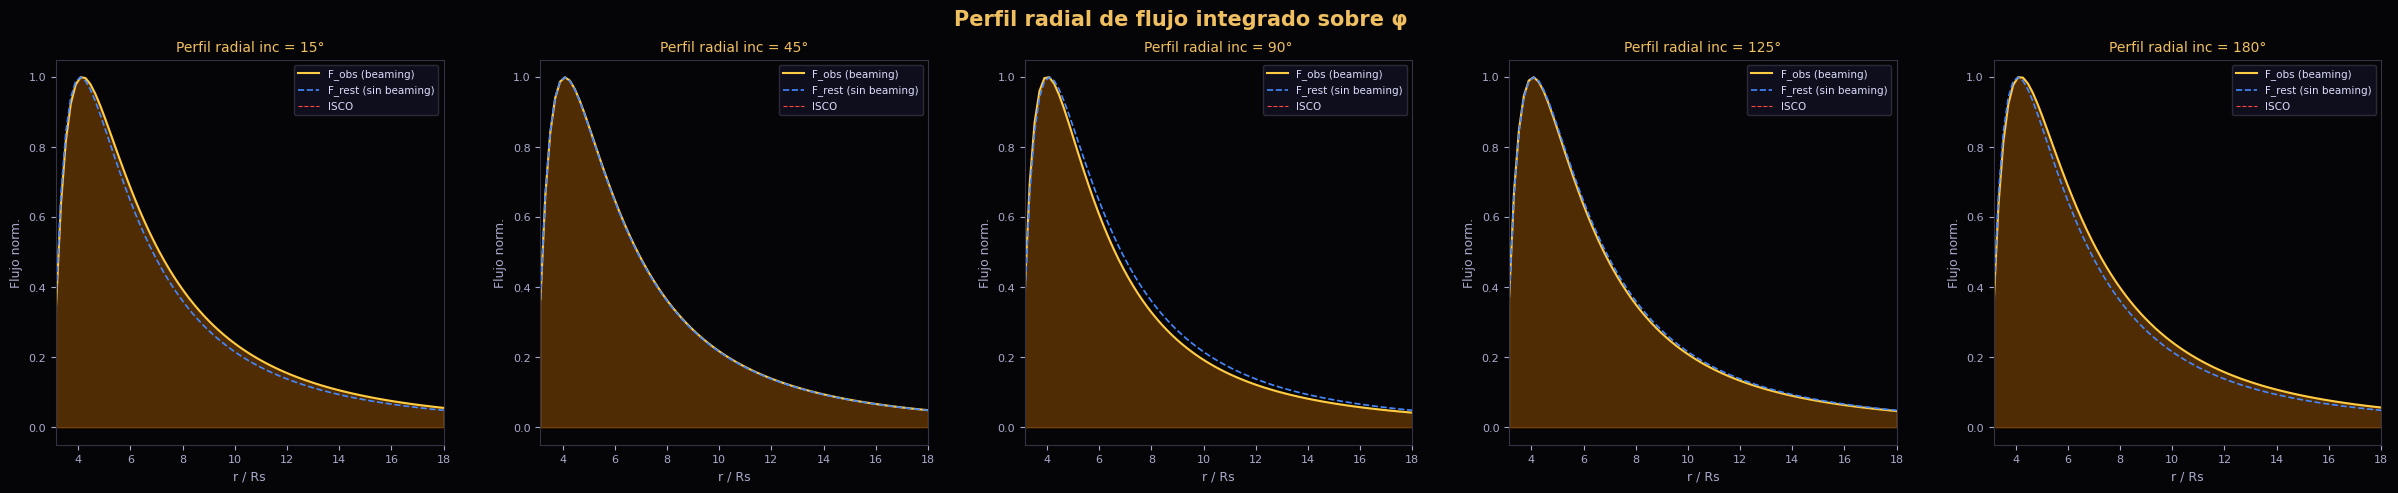


 Calculando mapas de emisión (beaming + redshift) — Ángulos negativos…


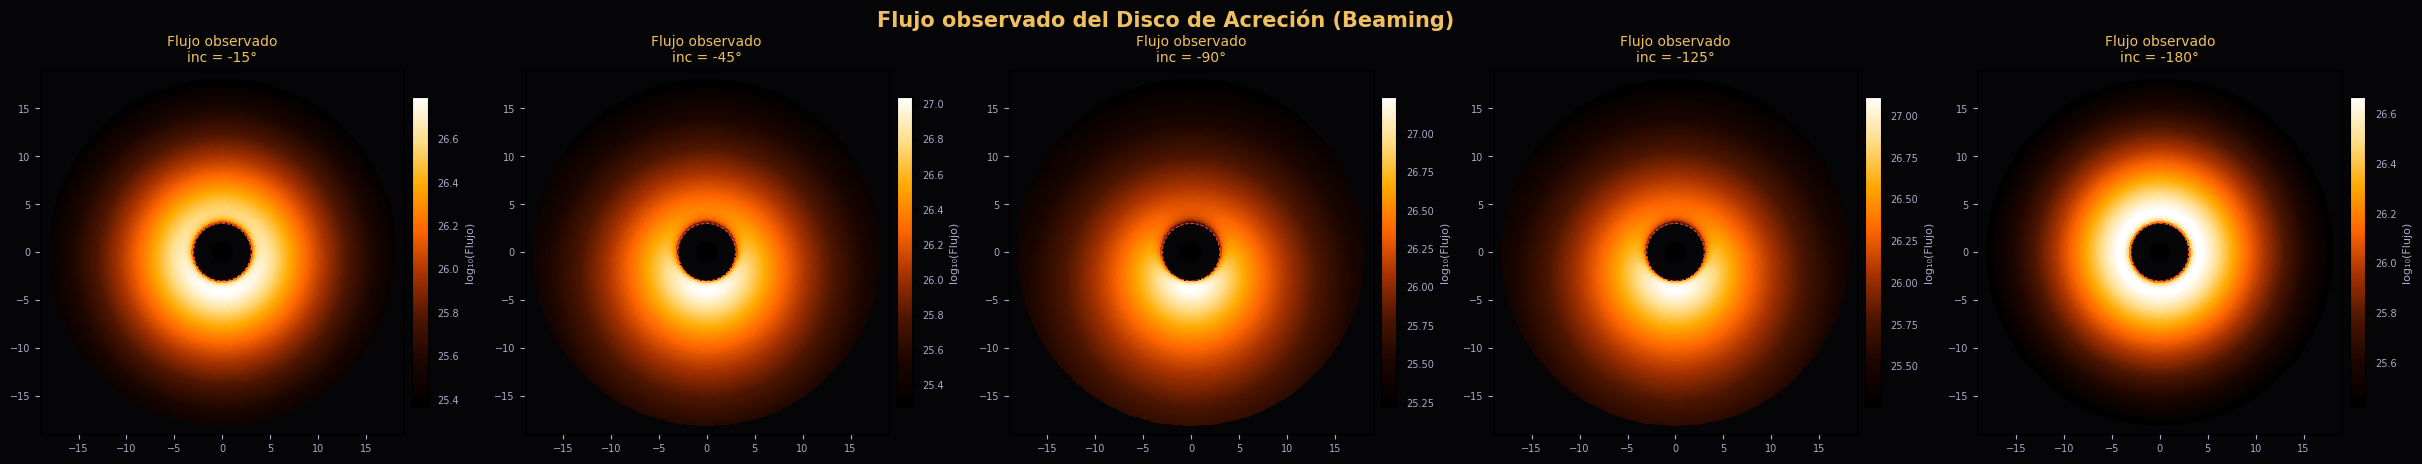

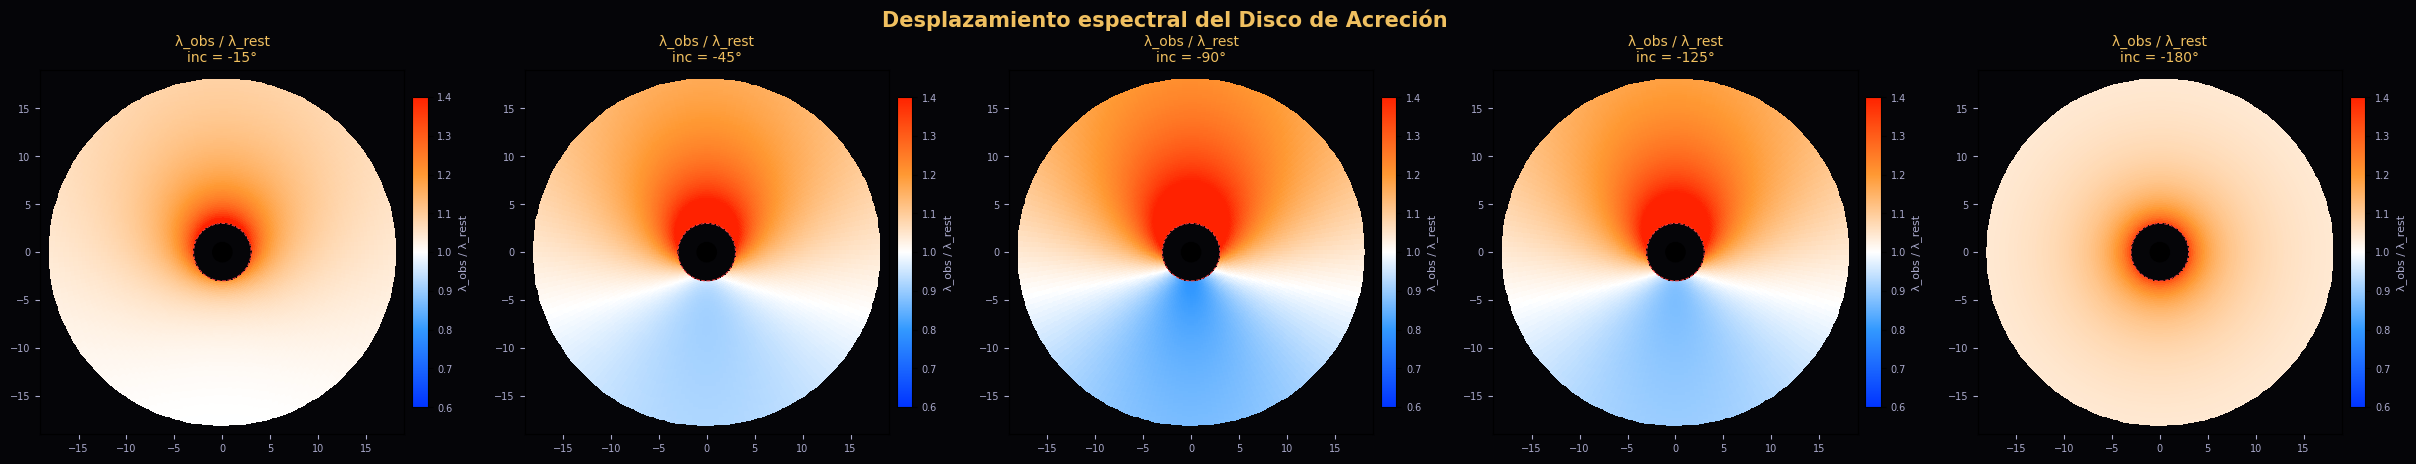

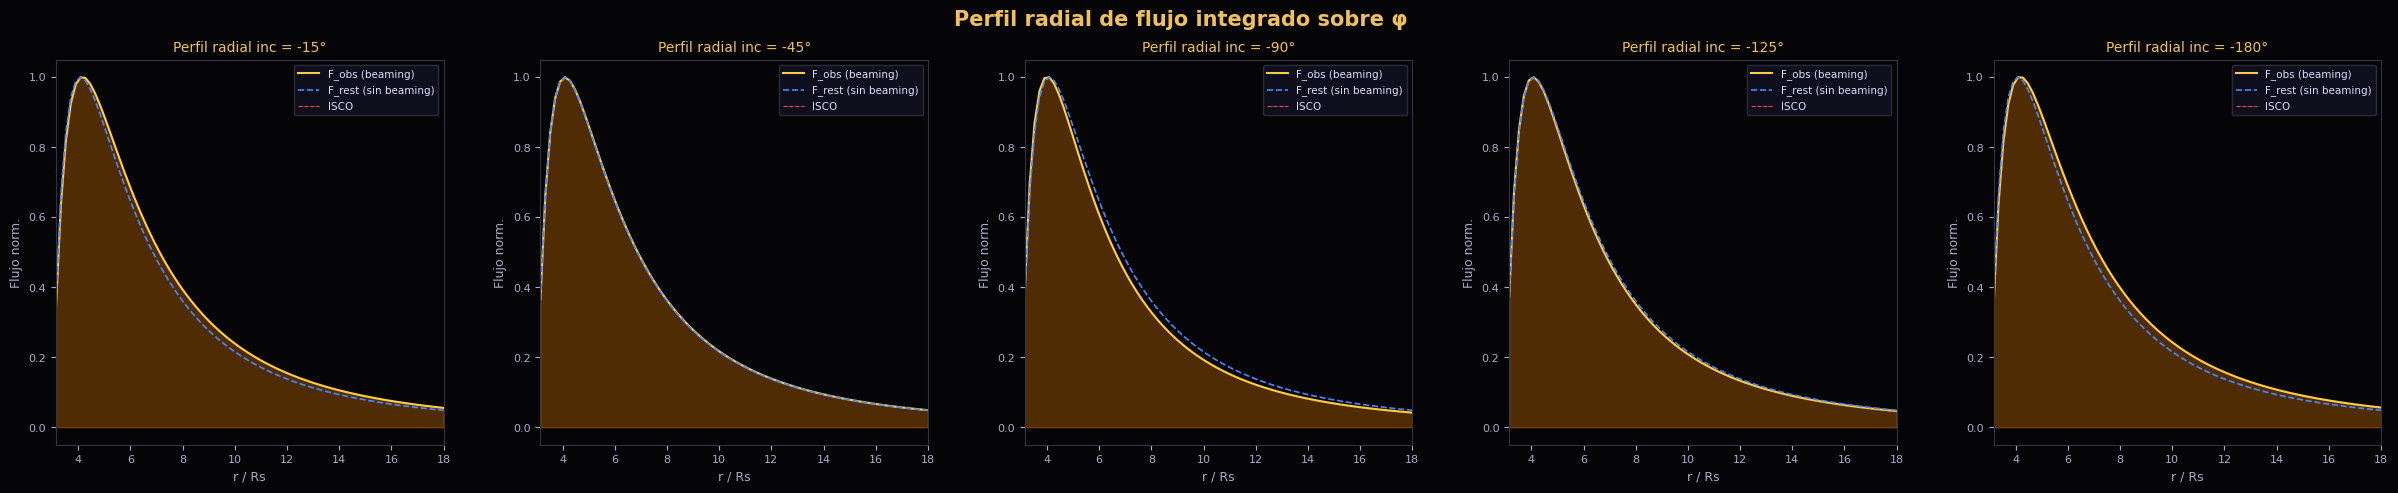

In [2]:
import numpy as np  # Importar NumPy para manejar arrays y operaciones matemáticas
import matplotlib.pyplot as plt  # Importar Matplotlib para crear gráficos
import matplotlib.gridspec as gridspec  # Para organizar subgráficos en una cuadrícula
from matplotlib.colors import LinearSegmentedColormap, Normalize  # Para mapas de colores personalizados
from matplotlib.patches import Circle  # Para dibujar círculos y flechas en gráficos
from scipy.integrate import odeint  # Para integrar ecuaciones diferenciales ordinarias

# UNIDADES DE AÑO LUZ (Light-Year Units)
c_SI = 299792458  # Velocidad de la luz en metros por segundo (valor SI)
c = 1  # Velocidad de la luz en unidades relativistas (adimensional en años-luz/año)
UT = 365.25 * 86400  # Segundos en un año (365.25 días * 86400 segundos/día)
UL = c_SI * UT  # Unidad de longitud = año luz en metros
UV = UL / UT  # Unidad de velocidad = años-luz por año en metros por segundo
UA = UL / UT**2  # Unidad de aceleración = años-luz por año cuadrado

# CONSTANTES Y PARÁMETROS GLOBALES (en unidades de año luz)
G_SI = 6.674e-11  # Constante gravitacional en m³ kg⁻¹ s⁻² (valor SI)
M_sun_SI = 1.989e30  # Masa del Sol en kilogramos (valor SI)

# Convertir G a unidades de año luz: años-luz³ / (masa solar · año²)
G = G_SI * M_sun_SI * UT**2 / UL**3

M_sun = 1.0  # Masa del Sol en las nuevas unidades (1 masa solar)
M_BH = 10 * M_sun  # Masa del agujero negro en 10 masas solares

# Radio de Schwarzschild en años-luz
# Rs = 2 * G * M / c², con c = 1 en unidades relativistas
R_s = 2 * G * M_BH / c**2
R_isco = 3 * R_s  # Radio del innermost stable circular orbit (ISCO)

# Convertir a metros para visualización
R_s_m = R_s * UL  # Radio de Schwarzschild en metros
R_isco_m = R_isco * UL  # ISCO en metros

# ABERRACIÓN RELATIVISTA POR EL MOVIMIENTO DE LA TIERRA
v_tierra = np.array([0, 2.978e4, 0])  # Velocidad orbital de la Tierra en m/s (dirección y)
beta_vec = -v_tierra / c_SI  # Vector beta = velocidad / c, negativo para dirección opuesta
beta2 = np.sum(beta_vec**2)  # Norma al cuadrado del vector beta
gamma_earth = 1 / np.sqrt(1 - beta2)  # Factor de Lorentz para la Tierra
nprima_ecl = np.array([0, 0, 1])  # Dirección eclíptica (asumir eje z)
dot = beta_vec @ nprima_ecl  # Producto punto entre beta_vec y dirección
beta_earth = np.sqrt(beta2)  # Norma de beta
cos_theta_earth = dot / beta_earth  # Coseno del ángulo entre velocidad y dirección
z_earth = gamma_earth * (1 - beta_earth * cos_theta_earth) - 1  # Redshift por movimiento de la Tierra
factor_earth = (1 + z_earth)**3  # Factor de corrección para flujo (1+z)^3

#DINÁMICA NEWTONIANA

def Vel_cir(r):
    """Calcular la velocidad circular kepleriana en el radio r."""
    return np.sqrt(G * M_BH / r)  # Fórmula: v = sqrt(G M / r)

def T_orb(r):
    """Calcular el período orbital kepleriano en el radio r."""
    return 2 * np.pi * r / Vel_cir(r)  # Fórmula: T = 2π r / v

def Equ_mov(state, t):
    """
    Sistema de ecuaciones diferenciales ordinarias para movimiento gravitacional 2D.
    state = [x, y, vx, vy] representa posición y velocidad.
    """
    x, y, vx, vy = state  # Desempaquetar el estado
    r = np.sqrt(x**2 + y**2)  # Calcular la distancia radial
    # Añadir fuerza de fricción débil para simular acreción
    drag = -5e-5  # Coeficiente de arrastre
    ax = -G * M_BH * x / r**3 + drag * vx  # Aceleración en x: gravedad + fricción
    ay = -G * M_BH * y / r**3 + drag * vy  # Aceleración en y: gravedad + fricción
    return [vx, vy, ax, ay]  # Retornar derivadas: [dx/dt, dy/dt, dvx/dt, dvy/dt]

def Simulacion(n_particles=2000, t_max=None, n_steps=1500):
    """
    Simular N partículas con condiciones iniciales casi circulares.
    Las partículas se distribuyen entre ISCO y 20 R_s.
    """
    np.random.seed(42)  # Fijar semilla para reproducibilidad

    # Radios distribuidos uniformemente
    r_min = R_isco * 1.05  # Radio mínimo ligeramente mayor que ISCO
    r_max = 20 * R_s  # Radio máximo 20 veces Rs
    radii = np.random.uniform(r_min, r_max, n_particles)  # Generar radios aleatorios
    angles = np.random.uniform(0, 2*np.pi, n_particles)  # Ángulos aleatorios

    # Perturbación radial pequeña (excentricidad ≈ 0.05)
    ecc = np.random.uniform(0, 0.08, n_particles)  # Excentricidades aleatorias

    particles = []  # Lista para almacenar las trayectorias
    for i in range(n_particles):
        r = radii[i]  # Radio de la partícula i
        phi = angles[i]  # Ángulo inicial
        v_c = Vel_cir(r) * (1 + ecc[i] * np.random.choice([-1, 1]))  # Velocidad con perturbación

        x = r * np.cos(phi)  # Posición inicial x
        y = r * np.sin(phi)  # Posición inicial y
        vx = -v_c * np.sin(phi)  # Velocidad inicial vx (tangencial)
        vy = v_c * np.cos(phi)  # Velocidad inicial vy (tangencial)

        T = T_orb(r)  # Período orbital
        if t_max is None:
            t_max_i = 3 * T  # Tiempo máximo 3 períodos si no especificado
        else:
            t_max_i = t_max

        t = np.linspace(0, t_max_i, n_steps)  # Array de tiempos
        sol = odeint(Equ_mov, [x, y, vx, vy], t,
                     rtol=1e-9, atol=1e-12)  # Integrar EDOs

        # Eliminar partículas que caen al agujero negro
        r_traj = np.sqrt(sol[:, 0]**2 + sol[:, 1]**2)  # Radio a lo largo de la trayectoria
        mask = r_traj > R_s * 1.1  # Máscara para radios > 1.1 Rs
        if mask.sum() > 10:  # Si hay suficientes puntos
            particles.append({
                'x': sol[mask, 0],  # Posiciones x filtradas
                'y': sol[mask, 1],  # Posiciones y filtradas
                'vx': sol[mask, 2],  # Velocidades vx filtradas
                'vy': sol[mask, 3],  # Velocidades vy filtradas
                'r0': r,  # Radio inicial
                'r_traj': r_traj[mask],  # Radios filtrados
            })

    return particles  # Retornar lista de partículas

# EFECTOS RELATIVISTAS

def Factor_L(v):
    """Calcular el factor de Lorentz γ = 1/√(1 - v²/c²)."""
    beta = np.clip(np.abs(v) / c, 0, 0.9999)  # Calcular β = |v| / c, limitado entre 0 y 0.9999 para evitar errores numéricos
    return 1.0 / np.sqrt(1 - beta**2)  # Retornar γ usando la fórmula relativista estándar

def Beaming_r(flux_rest, gamma, cos_theta):
    """
    Calcular el beaming relativista.
    F_obs = F_rest / [γ(1 - β cos θ)]^3
    θ: ángulo entre velocidad y línea de visión.
    """
    beta = np.sqrt(1 - 1/gamma**2)  # Calcular β = √(1 - 1/γ²) desde el factor de Lorentz
    doppler = gamma * (1 - beta * cos_theta)  # Calcular el factor Doppler relativista
    doppler = np.clip(doppler, 1e-6, 1e6)  # Limitar el factor Doppler para estabilidad numérica
    return flux_rest / doppler**3  # Retornar el flujo observado con beaming relativista

def Doppler(lambda_rest, gamma, cos_theta):
    """
    Calcular el desplazamiento Doppler relativista.
    λ_obs = λ_rest · γ(1 - β cos θ)
    """
    beta = np.sqrt(1 - 1/gamma**2)  # Calcular β desde el factor de Lorentz γ
    return lambda_rest * gamma * (1 - beta * cos_theta)  # Retornar la longitud de onda observada con desplazamiento Doppler

def Redshitf(lambda_emit, r):
    """
    Calcular el corrimiento al rojo gravitacional.
    λ_obs = λ_emit / √(1 - R_s/r)
    """
    factor = np.sqrt(1 - R_s / np.clip(r, R_s*1.01, 1e20))  # Calcular el factor gravitacional, limitando r para evitar división por cero
    return lambda_emit / factor  # Retornar la longitud de onda con corrimiento al rojo gravitacional

def T_disco(r):
    """
    Calcular el perfil de temperatura del disco (aproximación Shakura-Sunyaev).
    T(r) ∝ r^{-3/4} · (1 - √(R_isco/r))^{1/4}
    """
    if r <= R_isco:
        return 0  # Retornar temperatura cero si está dentro del radio ISCO
    T_max = 1e7  # Temperatura máxima en Kelvin
    x = R_isco / r  # Calcular la razón R_isco / r
    return T_max * (r / R_isco)**(-3/4) * max((1 - np.sqrt(x)), 0)**0.25  # Retornar la temperatura usando el perfil de Shakura-Sunyaev

#MAPA DE EMISIÓN OBSERVADA (beaming + redshift)

def Mapa_Disco(N_r=80, N_phi=200, obs_angle_deg=75):
    """
    Para un disco kepleriano, calcula:
    - Flujo observado (con beaming)
    - Longitud de onda observada (Doppler + gravit.)
    - Temperatura local
    Ángulo de observación medido desde el eje polar (inclinación).
    """
    obs_inc = np.radians(obs_angle_deg)  # Convertir ángulo de observación de grados a radianes

    r_arr   = np.linspace(R_isco * 1.05, 18 * R_s, N_r)  # Array de radios desde ISCO hasta 18 Rs
    phi_arr = np.linspace(0, 2*np.pi, N_phi)  # Array de ángulos azimutales
    PHI, R  = np.meshgrid(phi_arr, r_arr)  # Crear malla 2D para phi y r

    # Velocidad kepleriana
    V_kep = np.sqrt(G * M_BH / R)  # Calcular velocidad kepleriana usando ley de Kepler
    # Componente de la velocidad a lo largo de la línea de visión
    # v_los = v_phi · sin(phi) · sin(inc)
    V_los = V_kep * np.sin(PHI) * np.sin(obs_inc)  # Componente de velocidad hacia el observador

    GAMMA = Factor_L(V_kep)  # Calcular factor de Lorentz para cada punto
    COS_THETA = V_los / V_kep  # Calcular coseno del ángulo entre velocidad y línea de visión

    # Flujo en reposo ∝ T^4 (cuerpo negro)
    T_mat = np.vectorize(T_disco)(R)  # Calcular temperatura en cada punto de la malla
    F_rest = np.where(T_mat > 0, T_mat**4, 0)  # Flujo en reposo proporcional a T^4

    # Flujo observado con beaming
    F_obs = Beaming_r(F_rest, GAMMA, COS_THETA)  # Aplicar beaming relativista

    # Longitud de onda emitida (pico de cuerpo negro, Ley de Wien)
    b_wien = 2.898e-3  # Constante de Wien en metros·Kelvin
    lam_rest = np.where(T_mat > 0, b_wien / T_mat * 1e9, 0)  # Longitud de onda en reposo en nm

    # Doppler + corrimiento gravitacional
    lam_doppler = Doppler(lam_rest, GAMMA, COS_THETA)  # Aplicar desplazamiento Doppler
    lam_obs     = Redshitf(lam_doppler, R)  # Aplicar corrimiento gravitacional

    # Corrección por aberración relativista de la Tierra
    F_obs *= factor_earth  # Multiplicar flujo por factor de aberración terrestre
    lam_obs *= (1 + z_earth)  # Multiplicar longitud de onda por factor de redshift terrestre

    return R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA  # Retornar matrices calculadas

# VISUALIZACIÓN

def make_black_hole_colormap():
    """Colormap disco de acreción: negro → naranja → amarillo → blanco."""
    colors = ['#000000', '#1a0500', '#4d1500', '#a83200',  # Definir colores desde negro hasta naranja
              '#ff6600', '#ffaa00', '#ffdd88', '#ffffff']  # Continuar con amarillo y blanco
    return LinearSegmentedColormap.from_list('accretion', colors, N=512)  # Crear colormap personalizado

def plot_simulation(particles, title="Dinámica Newtoniana del Disco de Acreción"):
    """Figura 1: trayectorias de las partículas, snapshot + trayectorias."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7.5),  # Crear figura con dos paneles
                              facecolor='#050508')  # Fondo oscuro
    fig.suptitle(title, color='#f0c060', fontsize=15,  # Título de la figura
                 fontweight='bold', y=0.97)

    for ax in axes:  # Configurar estilo de los ejes
        ax.set_facecolor('#050508')  # Fondo oscuro para ejes
        for sp in ax.spines.values():  # Bordes de los ejes
            sp.set_color('#333344')  # Color gris para bordes
        ax.tick_params(colors='#aaaacc')  # Color de ticks
        ax.xaxis.label.set_color('#aaaacc')  # Color de etiquetas x
        ax.yaxis.label.set_color('#aaaacc')  # Color de etiquetas y

    scale = R_s  # Escala para normalizar posiciones
    cmap_disk = make_black_hole_colormap()  # Colormap para el disco

    # ── Panel izquierdo: snapshot (posición final)
    ax0 = axes[0]  # Primer eje (izquierdo)
    ax0.set_title("Snapshot final", color='#f0c060', fontsize=12)  # Título del panel

    # Color por radio
    snap_x, snap_y, snap_r = [], [], []  # Listas para posiciones finales
    for p in particles:  # Recorrer partículas
        snap_x.append(p['x'][-1] / scale)  # Posición x final normalizada
        snap_y.append(p['y'][-1] / scale)  # Posición y final normalizada
        snap_r.append(p['r_traj'][-1] / scale)  # Radio final normalizado
    snap_x, snap_y, snap_r = map(np.array, [snap_x, snap_y, snap_r])  # Convertir a arrays

    norm_r = Normalize(vmin=snap_r.min(), vmax=snap_r.max())  # Normalización para colormap
    sc = ax0.scatter(snap_x, snap_y, c=snap_r, cmap=cmap_disk,  # Scatter plot coloreado por radio
                     s=4, alpha=0.85, norm=norm_r, zorder=3)

    # Agujero negro
    bh = Circle((0, 0), R_s/scale, color='black', zorder=10)  # Círculo para el agujero negro
    ax0.add_patch(bh)  # Agregar al eje
    isco_circle = Circle((0, 0), R_isco/scale, fill=False,  # Círculo para ISCO
                          edgecolor='#ff4444', linewidth=0.8,
                          linestyle='--', zorder=5, label=f"ISCO = {R_isco/scale:.1f} Rs")
    ax0.add_patch(isco_circle)  # Agregar ISCO

    lim = 22  # Límite de ejes
    ax0.set_xlim(-lim, lim); ax0.set_ylim(-lim, lim)  # Establecer límites
    ax0.set_aspect('equal')  # Aspecto igual
    ax0.set_xlabel("x / Rs"); ax0.set_ylabel("y / Rs")  # Etiquetas
    ax0.legend(loc='upper right', fontsize=9, facecolor='#111122',  # Leyenda
               edgecolor='#334', labelcolor='#ffaaaa')
    cbar = fig.colorbar(sc, ax=ax0, fraction=0.04, pad=0.02)  # Barra de color
    cbar.set_label("r / Rs", color='#aaaacc'); cbar.ax.yaxis.set_tick_params(color='#aaaacc')  # Etiqueta barra
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaacc')  # Color ticks barra

    # ── Panel derecho: trayectorias (muestra 60 partículas)
    ax1 = axes[1]  # Segundo eje (derecho)
    ax1.set_title("Trayectorias de partículas (selección)", color='#f0c060', fontsize=12)  # Título del panel

    shown = particles[::max(1, len(particles)//60)]  # Seleccionar subconjunto de partículas
    for p in shown:  # Recorrer partículas seleccionadas
        r_norm = p['r0'] / (20 * R_s)  # Normalizar radio inicial para colormap
        col = cmap_disk(r_norm)  # Color basado en radio
        ax1.plot(p['x'] / scale, p['y'] / scale,  # Plotear trayectoria
                 color=col, linewidth=0.5, alpha=0.6)

    bh1 = Circle((0, 0), R_s/scale, color='black', zorder=10)  # Agujero negro
    ax1.add_patch(bh1)
    isco1 = Circle((0, 0), R_isco/scale, fill=False,  # ISCO
                   edgecolor='#ff4444', linewidth=0.8, linestyle='--', zorder=5)
    ax1.add_patch(isco1)

    ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim)  # Límites
    ax1.set_aspect('equal')  # Aspecto igual
    ax1.set_xlabel("x / Rs"); ax1.set_ylabel("y / Rs")  # Etiquetas

    plt.tight_layout()  # Ajustar layout


def plot_flux_maps(obs_angles=(15, 45, 75)):
    """
    Mostrar solo los mapas de flujo observado con beaming
    para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)

    fig.suptitle("Flujo observado del Disco de Acreción (Beaming)",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)

    cmap_flux = make_black_hole_colormap()

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        X = R * np.cos(PHI) / R_s
        Y = R * np.sin(PHI) / R_s

        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')
        F_log = np.log10(np.clip(F_obs, 1, None))
        pc = ax.pcolormesh(X, Y, F_log, cmap=cmap_flux, shading='auto')
        bh = Circle((0, 0), 1.0, color='black', zorder=5)
        ax.add_patch(bh)
        isco = Circle((0, 0), 3.0, fill=False, edgecolor='#ff4444', linewidth=0.7,
                      linestyle='--', zorder=6)
        ax.add_patch(isco)
        ax.set_aspect('equal')
        ax.set_xlim(-19, 19); ax.set_ylim(-19, 19)
        ax.set_title(f"Flujo observado\ninc = {inc}°", color='#f0c060', fontsize=10)
        ax.tick_params(colors='#aaaacc', labelsize=7)
        cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02)
        cb.set_label("log₁₀(Flujo)", color='#aaaacc', fontsize=8)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaaacc', fontsize=7)

    plt.show()


def plot_spectral_ratio_maps(obs_angles=(15, 45, 75)):
    """
    Mostrar solo los mapas de desplazamiento espectral
    λ_obs / λ_rest para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)

    fig.suptitle("Desplazamiento espectral del Disco de Acreción",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)

    cmap_shift = LinearSegmentedColormap.from_list(
        'doppler', ['#0033ff', '#3399ff', '#ffffff', '#ff9933', '#ff2200'], N=512)

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        X = R * np.cos(PHI) / R_s
        Y = R * np.sin(PHI) / R_s

        b_wien = 2.898e-3
        lam_rest_map = np.where(T_mat > 0, b_wien / T_mat * 1e9, np.nan)
        ratio = np.where(lam_rest_map > 0, lam_obs / lam_rest_map, np.nan)

        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')
        pc = ax.pcolormesh(X, Y, ratio, cmap=cmap_shift, shading='auto', vmin=0.6, vmax=1.4)
        bh = Circle((0, 0), 1.0, color='black', zorder=5)
        ax.add_patch(bh)
        isco = Circle((0, 0), 3.0, fill=False, edgecolor='#ff4444', linewidth=0.7,
                      linestyle='--', zorder=6)
        ax.add_patch(isco)
        ax.set_aspect('equal')
        ax.set_xlim(-19, 19); ax.set_ylim(-19, 19)
        ax.set_title(f"λ_obs / λ_rest\ninc = {inc}°", color='#f0c060', fontsize=10)
        ax.tick_params(colors='#aaaacc', labelsize=7)
        cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02)
        cb.set_label("λ_obs / λ_rest", color='#aaaacc', fontsize=8)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaaacc', fontsize=7)

    plt.show()


def plot_radial_flux_profiles(obs_angles=(15, 45, 75)):
    """
    Mostrar solo los perfiles radiales de flujo integrado
    para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)

    fig.suptitle("Perfil radial de flujo integrado sobre φ",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        r_vals = R[:, 0] / R_s
        flux_integrated = np.nansum(F_obs, axis=1)
        flux_rest_int = np.nansum(T_mat**4, axis=1)

        fn = flux_integrated / max(flux_integrated.max(), 1)
        fr = flux_rest_int / max(flux_rest_int.max(), 1)

        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')
        for sp in ax.spines.values():
            sp.set_color('#333344')
        ax.tick_params(colors='#aaaacc', labelsize=8)
        ax.fill_between(r_vals, fn, alpha=0.3, color='#ff8800')
        ax.plot(r_vals, fn, color='#ffcc44', linewidth=1.5, label='F_obs (beaming)')
        ax.plot(r_vals, fr, color='#4488ff', linewidth=1.2, linestyle='--', label='F_rest (sin beaming)')
        ax.axvline(3, color='#ff4444', linewidth=0.8, linestyle='--', label='ISCO')
        ax.set_xlabel("r / Rs", color='#aaaacc', fontsize=9)
        ax.set_ylabel("Flujo norm.", color='#aaaacc', fontsize=9)
        ax.set_title(f"Perfil radial inc = {inc}°", color='#f0c060', fontsize=10)
        ax.legend(fontsize=7.5, facecolor='#111122', edgecolor='#334', labelcolor='#ddddff')
        ax.set_xlim(r_vals.min(), r_vals.max())

    plt.show()


# MAIN

if __name__ == "__main__":  # Si el script se ejecuta directamente
    print("   DISCO DE ACRECIÓN — Simulación Relativista")  # Imprimir título
    print(f"   M_BH = 10 M☉  |  Rs = {R_s:.2e} años-luz = {R_s_m/1e3:.2f} km")  # Imprimir masa y Rs
    print(f"   ISCO = {R_isco:.2e} años-luz = {R_isco_m/1e3:.2f} km")  # Imprimir ISCO
    print(f"   Unidades: L = año-luz, T = año, G = {G:.3e} (años-luz)³/(M_sun·año²)")  # Unidades

    print("\n Simulando partículas (dinámica newtoniana)…")  # Mensaje de simulación
    particles = Simulacion(n_particles=10000, n_steps=1200)  # Simular partículas
    print(f"       {len(particles)} partículas simuladas.")  # Número de partículas
    plot_simulation(particles)  # Plotear simulación

    Angulos = [15, 45, 90, 125, 180]  # Ángulos de observación para mapas

    print("\n Calculando mapas de emisión (beaming + redshift) — Ángulos positivos…")  # Mensaje mapas positivos
    plot_flux_maps(obs_angles=np.array(Angulos))
    plot_spectral_ratio_maps(obs_angles=np.array(Angulos))
    plot_radial_flux_profiles(obs_angles=np.array(Angulos))

    print("\n Calculando mapas de emisión (beaming + redshift) — Ángulos negativos…")  # Mensaje mapas negativos
    plot_flux_maps(obs_angles= -np.array(Angulos))
    plot_spectral_ratio_maps(obs_angles= -np.array(Angulos))
    plot_radial_flux_profiles(obs_angles= -np.array(Angulos))
